<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%EC%8A%A4%ED%94%84%EB%A6%B0%ED%8A%B8%E1%84%86%E1%85%B5%E1%84%89%E1%85%A7%E1%86%AB%5D11_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_1%E1%84%90%E1%85%B5%E1%86%B7_%E1%84%80%E1%85%B5%E1%86%B7%E1%84%89%E1%85%A9%E1%84%8B%E1%85%A7%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 각 테이블 별로 간단한 EDA를 진행해보세요. 각 테이블이 어떤 의미와 특성을 가지고 있는지 파악하고, 테이블 간의 관계도 파악해보세요.  
2. 현재 주어진 데이터 셋으로 어떤 비즈니스 지표들을 만들 수 있는지 제시하고, 해당 지표들로 AARRR 프레임워크를 구성할 수 있는지 판단해주세요.    
3. (심화) Olist가 가장 집중적으로 관리해야한다고 여겨지는 지표들을 뽑아 핵심성과지표로 선정하고, Tableau로 시각화 해봅시다. 해당 지표들이 시계열을 따라 어떻게 변화하는지 그려보고, 급격하게 변화한 지점이 있다면 그 원인을 찾을 수 있는 대시보드를 구성해보세요.  
ex) 특정 제품의 매출량이 급격하게 상승하였음을 확인, 리뷰 데이터를 보니 최근 일주일 사이 해당 제품의 리뷰 건수가 급증했었음.

***

In [ ]:
import pandas as pd

In [ ]:
Customers = pd.read_csv('olist_customers_dataset.csv')
Order_Items = pd.read_csv('olist_order_items_dataset.csv')
Order_Payments = pd.read_csv('olist_order_payments_dataset.csv')
Order_Reviews = pd.read_csv('olist_order_reviews_dataset.csv')
Orders = pd.read_csv('olist_orders_dataset.csv')
Products = pd.read_csv('olist_products_dataset.csv')
Sellers = pd.read_csv('olist_sellers_dataset.csv')
Category_Translation = pd.read_csv('product_category_name_translation.csv')

***
# 1. EDA
***

## 데이터 탐색

In [ ]:
# 주문 상태
Orders.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00


In [ ]:
# 주문 상품
Order_Items.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29


In [ ]:
# 주문 결제
Order_Payments.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [ ]:
# 리뷰 정보
Order_Reviews.head(1)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59


In [ ]:
# 상품 정보
Products.head(1)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0


In [ ]:
# 고객 정보
Customers.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [ ]:
# 판매자 정보
Sellers.head(1)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP


In [ ]:
# 상품 카테고리 번역 정보
Category_Translation.head(1)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty


___

> ## 각 테이블의 의미와 특성

전체 데이터셋을 살펴본 결과,  
주문과 관련된 정보가 담긴 테이블,  
상품, 고객, 판매자의 기본 정보가 담긴 테이블,  
포르투갈어 카테고리의 영문 번역 정보가 담긴 테이블로 구분이 되었다.

[주문 정보]  
- `주문 상태` Orders = 주문ID/고객ID/주문상태/주문날짜/주문승인날짜/배송사전달날짜/고객배송날짜/예상배송날짜
- `주문 상품` Order_Items = 주문ID/주문품목번호/상품ID/판매자ID/배송준비마감일/상품가격/배송비  
- `주문 결제` Order_Payments = 주문ID/결제순서/결제유형/할부개월수/결제금액  
- `리뷰 정보` Order_Reviews = 리뷰ID/주문ID/리뷰점수/리뷰제목/리뷰내용/리뷰작성날짜/리뷰응답시간    

[기본 정보]  
- `상품 정보` Products = 상품ID/상품카테고리/상품명길이/상품설명길이/상품사진개수/상품무게(g)/상품길이(cm)/상품높이(cm)/상품너비(cm)  
- `고객 정보` Customers = 고객ID/고객고유번호/우편번호/도시/주   
- `판매자 정보` Sellers = 판매자ID/판매자우편번호/판매자도시/판매자주  

[번역 정보]
- `상품 카테고리 번역 정보` Category_Translation = 상품카테고리/상품카테고리(영어)

> ## 테이블 간 관계

**[주문 정보]**

1. **`Orders` ↔ `Order_Items`**  
   - **연결 키**: `order_id`  
   - **관계**: 주문 상태와 주문 상품 정보 연결.  
   - 예) 주문이 `delivered` 상태일 때, 주문 상품별 판매자 및 상품 가격, 배송비 분석 가능.

2. **`Orders` ↔ `Order_Payments`**  
   - **연결 키**: `order_id`  
   - **관계**: 주문 상태와 결제 정보를 연결.  
   - 예) 주문 상태와 결제 유형, 결제 금액 간의 관계 분석 가능.

3. **`Orders` ↔ `Order_Reviews`**  
   - **연결 키**: `order_id`  
   - **관계**: 주문 상태와 리뷰 정보 연결.  
   - 예) 배송 지연이 리뷰 점수에 미치는 영향 분석 가능.


**[기본 정보]**  

4. **`Order_Items` ↔ `Products`**  
   - **연결 키**: `product_id`  
   - **관계**: 주문 상품과 상품 정보를 연결.  
   - 예) 상품 카테고리별 판매량 및 배송비 분석.

5. **`Order_Items` ↔ `Sellers`**  
   - **연결 키**: `seller_id`  
   - **관계**: 판매자와 상품 주문 정보를 연결.  
   - 예) 판매자별 평균 배송 시간 및 고객 만족도 분석.

6. **`Orders` ↔ `Customers`**  
   - **연결 키**: `customer_id`  
   - **관계**: 고객과 주문 정보를 연결.  
   - 예) 지역별 주문 패턴 분석.

**[번역 정보]**  

7. **`Products` ↔ `Category_Translation`**  
   - **연결 키**: `product_category_name`  
   - **관계**: 상품 카테고리를 번역하여 영어로 표현.  



***
### 결측값
***

In [ ]:
Orders.isna().sum()  # 주문 승인 시간 - 160개
                     # 배송사 전달 시간 - 1783개
                     # 고객 배송 시간 - 2965개
                     # 예상배송날짜는 없음 (자동계산 되는 듯 함)

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [ ]:
Order_Items.isna().sum()  # 0

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [ ]:
Order_Payments.isna().sum()  # 0

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [ ]:
Order_Reviews.isna().sum()  # 리뷰제목/내용 결측값이 많지만 별점은 없음
                            # 굳이 결측치 제거 필요 X

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [ ]:
Products.isna().sum() # 카테고리, 상품명, 상품설명, 상품사진 미기재 - 610개
                      # 무게, 길이,높이,넓이 미기재 -  2개
                      # 상품 기본정보 이기때문에 결측치 제거 필요 X

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [ ]:
Customers.isna().sum()  # 0

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [ ]:
Sellers.isna().sum()  # 0

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [ ]:
Category_Translation.isna().sum()  # 0

product_category_name            0
product_category_name_english    0
dtype: int64

> 결측값 현황 및 처리 방안  
- 결측값이 있는 테이블
Orders, Order_Reviews, Products

- 처리 방안
Orders에서 배송 단계별 시간이 비어 있는 데이터가 많음.  
고객이 체감하는 예상 배송 날짜와 실제 배송 날짜가 고객 만족도에 더 큰 영향을 줄 수 있으므로, 이 부분의 결측값을 우선적으로 처리하는 것이 적절해 보임.


---
### 중복값
---

In [ ]:
Orders.duplicated().sum()

np.int64(0)

In [ ]:
Order_Items.duplicated().sum()

np.int64(0)

In [ ]:
Order_Payments.duplicated().sum()

np.int64(0)

In [ ]:
Order_Reviews.duplicated().sum()

np.int64(0)

In [ ]:
Products.duplicated().sum()

np.int64(0)

In [ ]:
Customers.duplicated().sum()

np.int64(0)

In [ ]:
Sellers.duplicated().sum()

np.int64(0)

In [ ]:
Category_Translation.duplicated().sum()

np.int64(0)

## 데이터 전처리

#### 이상치 전처리

In [ ]:
Orders[Orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

`delivered` 상태인데 결측치인 데이터만 제거

In [ ]:
Orders = Orders[~((Orders['order_status'] == 'delivered') & (Orders['order_delivered_customer_date'].isna()))]

In [ ]:
Orders[Orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

In [ ]:
Orders.dropna()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


***
### `상품 카테고리 번역 정보`를 `상품 정보`의 상품카테고리 열에 매핑하여 카테고리 영문화
***

In [ ]:
Products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [ ]:
# 상품 카테고리 번역 정보를 상품 정보에 매핑
Products = Products.merge(Category_Translation,
                          on='product_category_name',
                          how='left')

In [ ]:
Products.isna().sum()

product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

In [ ]:
# product_category_name_english 결측치
unmatched = Products[Products['product_category_name_english'].isnull()]

# 고유한 product_category_name 값 확인
unmatched_categories = unmatched['product_category_name'].unique()
unmatched_categories

array([nan, 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
      dtype=object)

In [ ]:
unique_english_categories = Category_Translation['product_category_name_english'].unique()
unique_english_categories

array(['health_beauty', 'computers_accessories', 'auto', 'bed_bath_table',
       'furniture_decor', 'sports_leisure', 'perfumery', 'housewares',
       'telephony', 'watches_gifts', 'food_drink', 'baby', 'stationery',
       'tablets_printing_image', 'toys', 'fixed_telephony',
       'garden_tools', 'fashion_bags_accessories', 'small_appliances',
       'consoles_games', 'audio', 'fashion_shoes', 'cool_stuff',
       'luggage_accessories', 'air_conditioning',
       'construction_tools_construction',
       'kitchen_dining_laundry_garden_furniture',
       'costruction_tools_garden', 'fashion_male_clothing', 'pet_shop',
       'office_furniture', 'market_place', 'electronics',
       'home_appliances', 'party_supplies', 'home_confort',
       'costruction_tools_tools', 'agro_industry_and_commerce',
       'furniture_mattress_and_upholstery', 'books_technical',
       'home_construction', 'musical_instruments',
       'furniture_living_room', 'construction_tools_lights',
       'indust

In [ ]:
missing_categories = pd.DataFrame({
    'product_category_name': ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
    'product_category_name_english': ['PC Gamer', 'Portable Kitchen and Food Preparers']
})
missing_categories

,product_category_name,product_category_name_english
0,pc_gamer,PC Gamer
1,portateis_cozinha_e_preparadores_de_alimentos,Portable Kitchen and Food Preparers


In [ ]:
Category_Translation = pd.concat([Category_Translation, missing_categories], ignore_index=True)
Category_Translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# Products와 Category_Translation 다시 병합
Products = Products.drop(columns=['product_category_name_english'])
Products = Products.merge(Category_Translation, on='product_category_name', how='left')

In [ ]:
Products.isna().sum()

product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    610
dtype: int64

In [ ]:
# product_category_name에 product_category_name_english 값 덮어쓰기
Products['product_category_name'] = Products['product_category_name_english']
Products = Products.drop(columns='product_category_name_english')
Products.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0


***

### 기타 전처리

In [ ]:
Orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [ ]:
# 시간 관련 열을 datetime으로 변환
time_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in time_columns:
    Orders[col] = pd.to_datetime(Orders[col], errors='coerce')

# 데이터 타입 확인
print(Orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


***

# 2. 비즈니스 지표

## AARRR 프레임워크

AARRR 프레임워크는 스타트업 및 온라인 서비스에서 고객의 행동을 추적하고 분석하기 위한 마케팅 및 비즈니스 분석 모델.  
이는 고객 여정(Customer Journey)의 각 단계를 체계적으로 분석하고 개선할 수 있도록 설계되었다.  

> ### AARRR 프레임워크를 구성할 수 있는지 판단

첫 번째 단계인 Acquisition(획득: 고객이 제품이나 서비스를 처음 알게 되고 방문하는 단계)부터 구성하기 어렵다.
- 현황: 현재 데이터셋에는 유입 채널, 가입일자, 마케팅 정보와 같은 획득 관련 메타데이터가 부족하다.  
- 대안: 고객의 customer_unique_id를 기준으로 첫 주문 데이터를 "신규 고객"으로 간주하여 분석을 진행할 수밖에 없다.

> AARRR 분석

#### 1. Acquisition (획득)

In [ ]:
Orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [ ]:
# 첫주문 데이터
first_orders = Orders.groupby('customer_id')['order_purchase_timestamp'].min()
first_orders

customer_id
00012a2ce6f8dcda20d059ce98491703   2017-11-14 16:08:26
000161a058600d5901f007fab4c27140   2017-07-16 09:40:32
0001fd6190edaaf884bcaf3d49edf079   2017-02-28 11:06:43
0002414f95344307404f0ace7a26f1d5   2017-08-16 13:09:20
000379cdec625522490c315e70c7a9fb   2018-04-02 13:42:17
                                           ...        
fffecc9f79fd8c764f843e9951b11341   2018-03-29 16:59:26
fffeda5b6d849fbd39689bb92087f431   2018-05-22 13:36:02
ffff42319e9b2d713724ae527742af25   2018-06-13 16:57:05
ffffa3172527f765de70084a7e53aae8   2017-09-02 11:53:32
ffffe8b65bbe3087b653a978c870db99   2017-09-29 14:07:03
Name: order_purchase_timestamp, Length: 99433, dtype: datetime64[ns]

전체 행의 개수가 그대로 이므로 1명의 고객이 1개의 주문으로 이루어진 데이터라는 것을 확인할 수 있다.

모든 데이터를 첫 주문으로 가정하고 추가 분석 실행함.

---

#### 2. Activation (활성화)

Aha-moment 가정  
1. 첫 주문 성공: 고객이 첫 번째 주문을 성공적으로 완료한 순간(order_status == 'delivered').  
2. 리뷰 작성: 첫 주문 후 긍정적 리뷰(review_score >= 4)를 남긴 경우.
3. 평균 활성화 기간: 고객의 첫 구매 이후 리뷰 작성까지의 기간.

In [ ]:
Orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [ ]:
# 주문의 상태 확인
first_order_status = Orders.groupby('customer_id')['order_status'].first()
first_order_status

customer_id
00012a2ce6f8dcda20d059ce98491703      delivered
000161a058600d5901f007fab4c27140      delivered
0001fd6190edaaf884bcaf3d49edf079      delivered
0002414f95344307404f0ace7a26f1d5      delivered
000379cdec625522490c315e70c7a9fb      delivered
                                       ...     
fffecc9f79fd8c764f843e9951b11341      delivered
fffeda5b6d849fbd39689bb92087f431      delivered
ffff42319e9b2d713724ae527742af25      delivered
ffffa3172527f765de70084a7e53aae8      delivered
ffffe8b65bbe3087b653a978c870db99    unavailable
Name: order_status, Length: 99433, dtype: object

In [ ]:
# 첫 주문이 성공적으로 완료된 고객 비율 계산
activation_rate = (first_order_status == 'delivered').mean()
print(f"첫 주문 성공률: {activation_rate:.2%}")

첫 주문 성공률: 97.02%


In [ ]:
# 첫 주문 데이터를 리뷰 데이터와 병합함
merged_data = pd.merge(Orders, Order_Reviews, on='order_id', how='left')

# 리뷰 점수 >= 4인 경우를 긍정적 리뷰로 간주함
positive_reviews = merged_data[merged_data['review_score'] >= 4]
positive_reviews

# 긍정적 리뷰 작성 고객 비율
positive_review_rate = len(positive_reviews) / len(merged_data)
print(f"첫 주문 후 긍정적 리뷰 작성 비율: {positive_review_rate:.2%}")


첫 주문 후 긍정적 리뷰 작성 비율: 76.48%


In [ ]:
# 리뷰 작성 날짜와 주문 날짜 간의 기간 계산
merged_data['time_to_aha'] = (
    pd.to_datetime(merged_data['review_creation_date'])
    - pd.to_datetime(merged_data['order_purchase_timestamp'])
).dt.days
# Aha-moment(긍정적 리뷰 작성)까지의 평균 기간 계산
average_time_to_aha = merged_data[merged_data['review_score'] >= 4]['time_to_aha'].mean()
print(f"평균 Aha-moment까지의 기간: {average_time_to_aha:.2f}일")


평균 Aha-moment까지의 기간: 11.02일


- 주문 처리 과정(결제, 승인, 배송 등)이 원활하게 작동하고 있다
- 첫 주문 후 대다수의 고객이 만족함. 하지만 약 23.52%의 고객은 긍정적이지 않은 경험을 함.
- Aha-moment의 기간은 약 11일, 이거를 줄인다면 충성고객이 될 가능성이 높아질 것이다.


___

#### 3. Retention (유지)

Olist 데이터셋의 특성상 Orders 테이블에서는 1명의 고객이 1개의 주문만 기록되어 있기 때문에,  
재구매율이나 평균 구매 간격을 직접적으로 계산할 수 없음.  
고객별로 구매 카테고리를 확인해서 긍정적 리뷰(review_score >= 4)를 남긴 고객을 충성 고객으로 가정하고,  
이들의 카테고리 선호도나 구매 경향 분석

In [ ]:
# 병합: 주문 → 리뷰 → 상품 → 카테고리
merged_data = pd.merge(Orders, Order_Reviews, on='order_id', how='left')  # 리뷰 정보 추가
merged_data = pd.merge(merged_data, Order_Items, on='order_id', how='left')  # 상품 정보 추가
merged_data = pd.merge(merged_data, Products, on='product_id', how='left')  # 상품 카테고리 정보 추가


In [ ]:
# review score 4점이상만 추출하고 충성고객으로 분류
loyal_customers = merged_data[merged_data['review_score'] >= 4]
print(loyal_customers['review_score'].unique())
loyal_customers.head()

[4. 5.]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,29.99,8.72,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,118.70,22.76,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,159.90,19.22,auto,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,...,19.90,8.72,stationery,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [ ]:
loyal_char1 = loyal_customers['product_category_name'].value_counts()
loyal_char1

product_category_name
bed_bath_table                         7916
health_beauty                          7566
sports_leisure                         6739
furniture_decor                        5956
computers_accessories                  5741
                                       ... 
la_cuisine                               10
Portable Kitchen and Food Preparers       7
fashion_childrens_clothes                 7
PC Gamer                                  6
security_and_services                     1
Name: count, Length: 73, dtype: int64

In [ ]:
loyal_char2 = loyal_customers.groupby('product_category_name')['review_score'].mean()
loyal_char2

product_category_name
PC Gamer                               4.500000
Portable Kitchen and Food Preparers    4.714286
agro_industry_and_commerce             4.654545
air_conditioning                       4.754630
art                                    4.741722
                                         ...   
stationery                             4.762846
tablets_printing_image                 4.671875
telephony                              4.704490
toys                                   4.780639
watches_gifts                          4.748258
Name: review_score, Length: 73, dtype: float64

In [ ]:
category_loyalty = pd.merge(loyal_char1,loyal_char2,on='product_category_name',how='left').reset_index()
category_loyalty.sort_values(by='count',ascending=False).head(10)

,product_category_name,count,review_score
0,bed_bath_table,7916,4.730798
1,health_beauty,7566,4.774253
2,sports_leisure,6739,4.759757
3,furniture_decor,5956,4.747482
4,computers_accessories,5741,4.731580
5,housewares,5263,4.757173
6,watches_gifts,4449,4.748258
7,telephony,3296,4.704490
8,garden_tools,3287,4.753879
9,auto,3247,4.732984


- bed_bath_table, health_beauty 순으로 리뷰 수가 많았다. 평균 점수는 4.7로 비등함
- 별점이 높으며, 리뷰 수가 많은 카테고리가 실제로 회사 매출의 핵심인가?
-> 'KPI 3. 매출관련'에 따르면 bed_bath_table, health_beauty, sports_leisure 등 카테고리 상품의 개수가 많아서 리뷰의 비중이 높다. 하지만 매출 비중이 크진않다.

---
- 배송비 부문

In [ ]:
Order_Payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [ ]:
merged_data = pd.merge(merged_data,Order_Payments,on='order_id',how='left')

In [ ]:
free_shipping = merged_data[merged_data['freight_value'] == 0]
free_shipping[['product_category_name','payment_value','freight_value']]


,product_category_name,payment_value,freight_value
238,furniture_decor,139.8,0.0
239,furniture_decor,139.8,0.0
495,watches_gifts,99.9,0.0
769,furniture_decor,69.9,0.0
792,watches_gifts,110.0,0.0
...,...,...,...
117789,watches_gifts,99.9,0.0
117998,watches_gifts,199.0,0.0
118270,furniture_decor,69.9,0.0
118330,watches_gifts,99.9,0.0


In [ ]:
free_shipping.groupby(['seller_id']).size()

seller_id
1f50f920176fa81dab994f9023523100     56
37be5a7c751166fbc5f8ccba4119e043      9
4869f7a5dfa277a7dca6462dcf3b52b2     57
7d13fca15225358621be4086e1eb0964    159
8581055ce74af1daba164fdbd55a40de      1
955fee9216a65b617aa5c0531780ce60    104
bc2ac6b95e1accce9858528ee566c17e      1
c826c40d7b19f62a09e2d7c5e7295ee2      2
cc419e0650a3c5ba77189a1882b7556a      1
dtype: int64

- 무료배송 조건을 제공한 셀러 수 9명!
- 셀러 id 7d13fca15225358621be4086e1eb0964 기준 무료배송을 진행한 상품은 무슨 상품일까?

In [ ]:
merged_data[merged_data['seller_id'] == '7d13fca15225358621be4086e1eb0964'].groupby('product_category_name').size()

product_category_name
audio              48
cool_stuff          2
electronics        15
market_place        2
perfumery           2
sports_leisure      2
watches_gifts     527
dtype: int64

watches_gifts 527건

---
- 유료 배송

In [ ]:
Paid_shipping = merged_data[merged_data['freight_value'] > 0]
Paid_shipping[['product_category_name','payment_value','freight_value']]


,product_category_name,payment_value,freight_value
0,housewares,18.12,8.72
1,housewares,2.00,8.72
2,housewares,18.59,8.72
3,perfumery,141.46,22.76
4,auto,179.12,19.22
...,...,...,...
119130,baby,195.00,20.10
119131,home_appliances_2,271.01,65.02
119132,computers_accessories,441.16,40.59
119133,computers_accessories,441.16,40.59


In [ ]:
Paid_shipping.groupby(['seller_id'])['freight_value'].size()

seller_id
0015a82c2db000af6aaaf3ae2ecb0532      3
001cca7ae9ae17fb1caed9dfb1094831    241
001e6ad469a905060d959994f1b41e4f      1
002100f778ceb8431b7a1020ff7ab48f     59
003554e2dce176b5555353e4f3555ac8      1
                                   ... 
ffcfefa19b08742c5d315f2791395ee5      1
ffdd9f82b9a447f6f8d4b91554cc7dd3     21
ffeee66ac5d5a62fe688b9d26f83f534     14
fffd5413c0700ac820c7069d66d98c89     62
ffff564a4f9085cd26170f4732393726     20
Name: freight_value, Length: 3095, dtype: int64

- 3095개 이므로 모든 셀러가 배송비를 받고있다.  
- 무료배송을 활성화한다면 이탈을 막고 유지가 가능하지 않을까?

***
#### 4. Revenue (수익화)

- 고객 유지:
    - 무료배송: 묶음배송, 빠른배송 서비스 제공.
    - 리스크: 물류 비용 증가, 재고 부담.
- 고객당 평균 매출(ARPU) 증대
    - 크로스셀링, 업셀링, 정기구독 도입, 고객군 분류하여 타겟 마케팅

In [ ]:
# 총 매출 계산
total_revenue = Order_Payments['payment_value'].sum()

# 총 주문 수 계산
total_orders = Order_Payments['order_id'].nunique()

# 객단가 계산
aov = total_revenue / total_orders
print(f"객단가: {aov:.2f}")


객단가: 160.99


In [ ]:
# 카테고리별 총 매출 계산
total_revenue_by_category = merged_data.groupby('product_category_name')['payment_value'].sum()

# 카테고리별 주문 수 계산
total_orders_by_category = merged_data.groupby('product_category_name')['order_id'].nunique()

# 객단가 계산
category_aov = total_revenue_by_category / total_orders_by_category
print(f"카테고리별 객단가:\n{category_aov}")


카테고리별 객단가:
product_category_name
PC Gamer                               271.803750
Portable Kitchen and Food Preparers    309.689286
agro_industry_and_commerce             652.365989
air_conditioning                       360.358340
art                                    153.430347
                                          ...    
stationery                             137.648243
tablets_printing_image                 127.125696
telephony                              116.025175
toys                                   159.529238
watches_gifts                          254.400096
Length: 73, dtype: float64


In [ ]:
top10 = category_aov.sort_values(ascending=False).head(10)
top10

product_category_name
computers                                1542.108011
fixed_telephony                           954.244470
small_appliances_home_oven_and_coffee     683.057600
agro_industry_and_commerce                652.365989
home_appliances_2                         533.615043
office_furniture                          512.188924
signaling_and_security                    489.200357
construction_tools_safety                 393.359461
musical_instruments                       371.340287
air_conditioning                          360.358340
dtype: float64

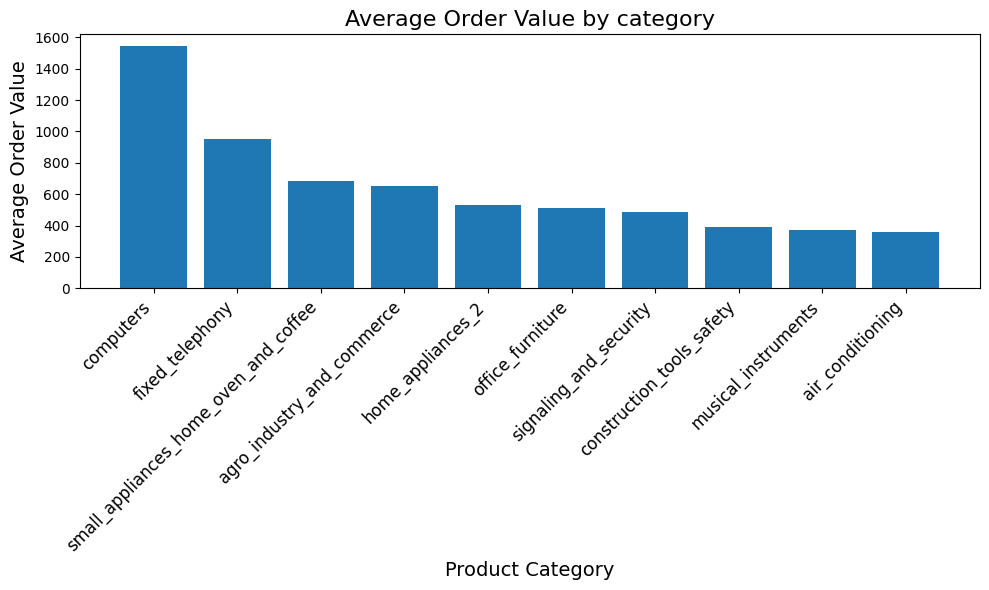

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values)
plt.title("Average Order Value by category", fontsize=16)
plt.xlabel("Product Category", fontsize=14)
plt.ylabel("Average Order Value", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

컴퓨터 카테고리의 평균 주문 금액이 다른 카테고리에 비해 월등히 높음

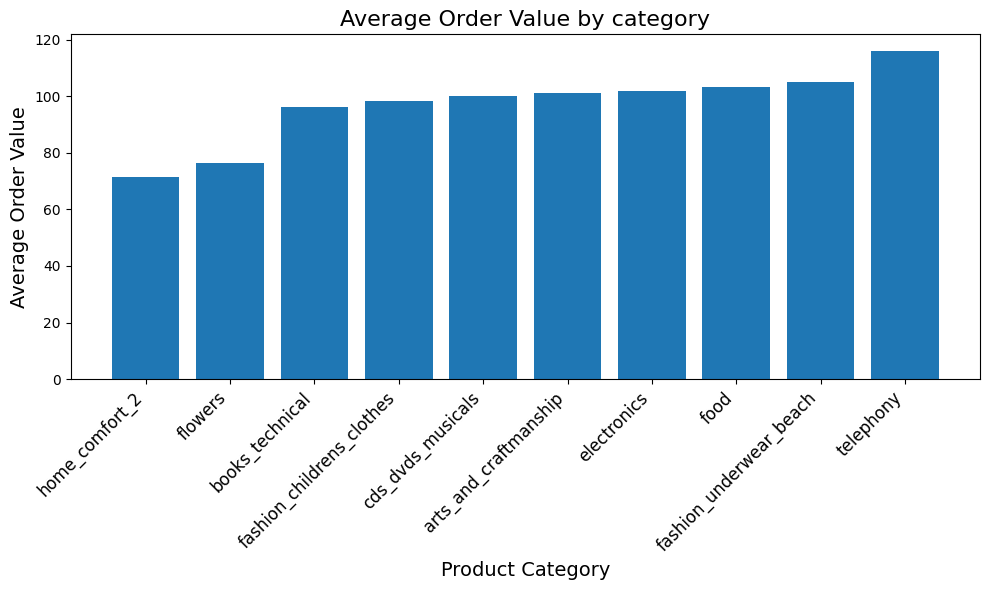

In [ ]:
new_top10 = category_aov.sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.bar(new_top10.index, new_top10.values)
plt.title("Average Order Value by category", fontsize=16)
plt.xlabel("Product Category", fontsize=14)
plt.ylabel("Average Order Value", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

객단가 증대 전략은 객단가가 낮은 카테고리에 집중하는 것이 효과적일 가능성이 크다.

- 컴퓨터 상품과 관련한 제품들을 포함하는 번들링 상품 제안하여 극대화
- 특정 금액 이상 구매 시 혜택 제공하여 평균 단가가 낮은 제품들도 일정 주문금액을 끌어올리는 전략 제언

***
### 5. Referral (추천)

긍정적 리뷰를 남긴 충성 고객(review_score >= 4)을 기준으로 잠재적인 추천 고객군을 선정.

In [ ]:
loyal_customers.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [ ]:
loyal_customers['product_category_name'].value_counts()

product_category_name
bed_bath_table                         7916
health_beauty                          7566
sports_leisure                         6739
furniture_decor                        5956
computers_accessories                  5741
                                       ... 
la_cuisine                               10
Portable Kitchen and Food Preparers       7
fashion_childrens_clothes                 7
PC Gamer                                  6
security_and_services                     1
Name: count, Length: 73, dtype: int64

- 상위 10개 카테고리를 추천 상품으로 선정후  
추천된 카테고리가 전체 매출의 몇 퍼센트를 차지하는지 확인하여  
추천활동의 기여도를 추출해도 좋을것 같다.  
 - 추천활동이 신규고객유입에 미친 영향을 파악하기 어렵다.

***

## 데이터셋에서 설정 가능한 KPI

1. `고객` 관련    
- 지역별 신규 고객 수: 특정 기간 동안 지역별 신규 고객 비율.  
- 재구매율: 고객 중 2회 이상 구매를 한 비율.  

2. `주문` 관련 (운영)  
- 정시, 조기, 지연 배송 분포 확인  
- 배송 지연률: 배송 예정 날짜(order_estimated_delivery_date)를 초과한 비율.   
- 평균 주문 처리 시간: 주문 생성 시점(order_purchase_timestamp)부터  
- 고객이 실제로 받은 시점(order_delivered_customer_date)까지 걸린 평균시간.

3. `매출` 관련  
- 카테고리별 매출: 각 상품 카테고리의 매출 비율.  
- 주문당 평균 매출: 주문 하나에서 발생하는 평균 결제 금액.

4. `리뷰 및 품질` 관련  
- 리뷰 점수 평균: 고객 리뷰 점수의 평균값.  
- 리뷰 작성율: 주문 대비 리뷰를 남긴 비율.

### 데이터셋 KPI 분석

#### 1. `고객` 관련

- 지역별 고객 수

In [ ]:
region_customer_counts = Customers['customer_city'].value_counts()
region_customer_counts

customer_city
sao paulo                   15540
rio de janeiro               6882
belo horizonte               2773
brasilia                     2131
curitiba                     1521
                            ...  
olhos d'agua                    1
pacotuba                        1
sao sebastiao do paraiba        1
benedito leite                  1
campos verdes                   1
Name: count, Length: 4119, dtype: int64

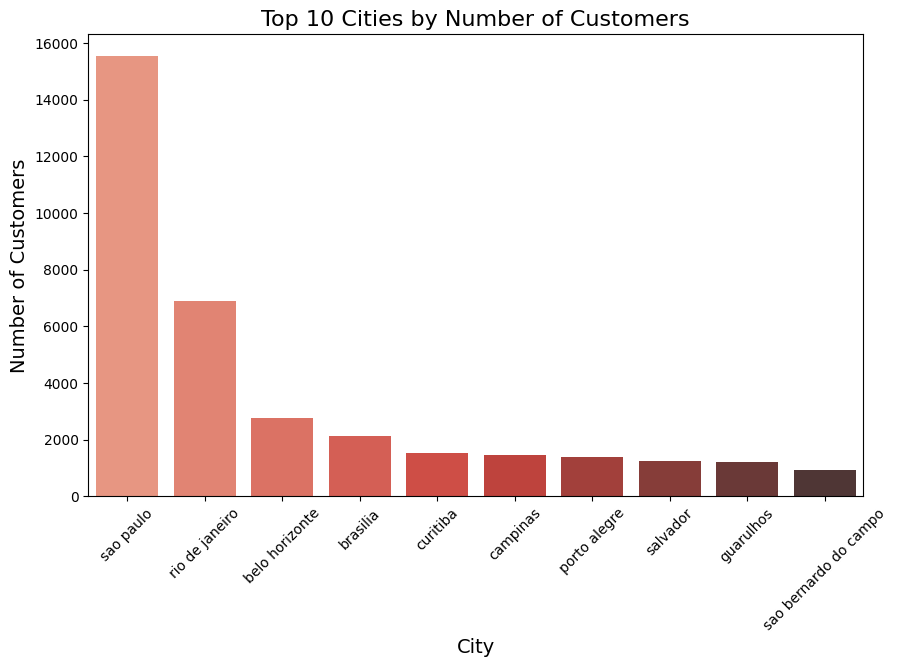

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_10_cities = region_customer_counts.head(10).reset_index()
top_10_cities.columns = ['City', 'Customer Count']

sns.barplot(data=top_10_cities, x='City', y='Customer Count', palette='Reds_d', hue='City')
plt.title('Top 10 Cities by Number of Customers', fontsize=16)
plt.xlabel('City', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(rotation=45)
plt.show()

#### 2. `주문` 관련 (운영)

- 배송 지연률: 배송 예정 날짜(order_estimated_delivery_date)를 초과한 비율.   

In [ ]:
# 배송 지연 여부 계산
Orders['is_delayed'] = Orders['order_delivered_customer_date'].dt.date > Orders['order_estimated_delivery_date'].dt.date
Orders['is_on_time'] = Orders['order_delivered_customer_date'].dt.date < Orders['order_estimated_delivery_date'].dt.date

In [ ]:
# 총 주문 수, 지연된 주문 수,정시 배송 수 계산
total_orders = Orders.shape[0]
delayed_orders = Orders['is_delayed'].sum()
on_time_orders = Orders['is_on_time'].sum()

In [ ]:
# 각 비율 계산
delay_rate = (delayed_orders / total_orders) * 100
on_time_rate = (on_time_orders / total_orders) * 100

In [ ]:
# 결과 출력
print(f"총 주문 수: {total_orders}")
print(f"지연된 주문 수: {delayed_orders} ({delay_rate:.2f}%)")
print(f"정시 배송 수: {on_time_orders} ({on_time_rate:.2f}%)")

총 주문 수: 99433
지연된 주문 수: 6535 (6.57%)
정시 배송 수: 88649 (89.15%)


In [ ]:
# 배송 상태 분류
Orders['delivery_status'] = Orders.apply(
    lambda row: 'Delayed' if row['is_delayed'] else 'On-Time',
    axis=1)

In [ ]:
status_counts = Orders['delivery_status'].value_counts()
status_counts

delivery_status
On-Time    92898
Delayed     6535
Name: count, dtype: int64

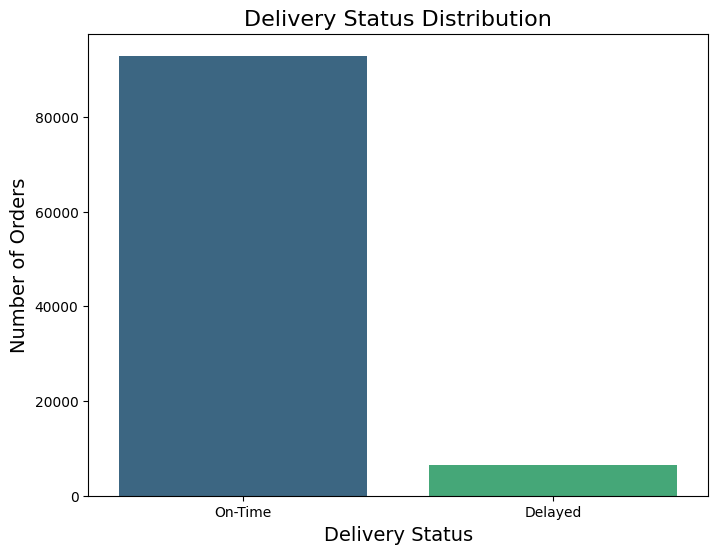

In [ ]:
# 막대그래프 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis', hue=status_counts.index)
plt.title('Delivery Status Distribution', fontsize=16)
plt.xlabel('Delivery Status', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.xticks(rotation=0)
plt.show()

- 평균 주문 처리 시간: 주문 생성 시점(order_purchase_timestamp)부터  
고객이 실제로 받은 시점(order_delivered_customer_date)까지 걸린 평균시간.

In [ ]:
# 주문 처리 시간 계산
Orders['processing_time'] = Orders['order_delivered_customer_date'] - Orders['order_purchase_timestamp']

# 평균 주문 처리 시간 계산
average_processing_time = Orders['processing_time'].mean()

# 결과 출력
print(f"평균 주문 처리 시간: {average_processing_time}")


평균 주문 처리 시간: 12 days 13:24:31.879068369


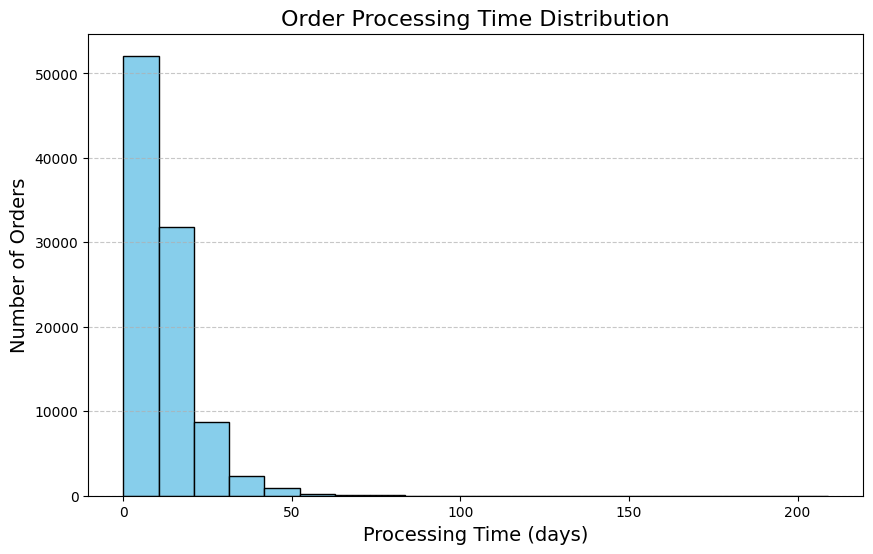

In [ ]:
# 히스토그램으로 처리 시간 분포 시각화
plt.figure(figsize=(10, 6))
Orders['processing_time'].dt.days.plot(kind='hist', bins=20)
plt.title('Order Processing Time Distribution', fontsize=16)
plt.xlabel('Processing Time (days)', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### 3. `매출` 관련  
- 카테고리별 해당 상품 개수 분석

In [ ]:
category_products = Products['product_category_name'].value_counts()
category_products

product_category_name
bed_bath_table               3029
sports_leisure               2867
furniture_decor              2657
health_beauty                2444
housewares                   2335
                             ... 
fashion_childrens_clothes       5
home_comfort_2                  5
PC Gamer                        3
security_and_services           2
cds_dvds_musicals               1
Name: count, Length: 73, dtype: int64

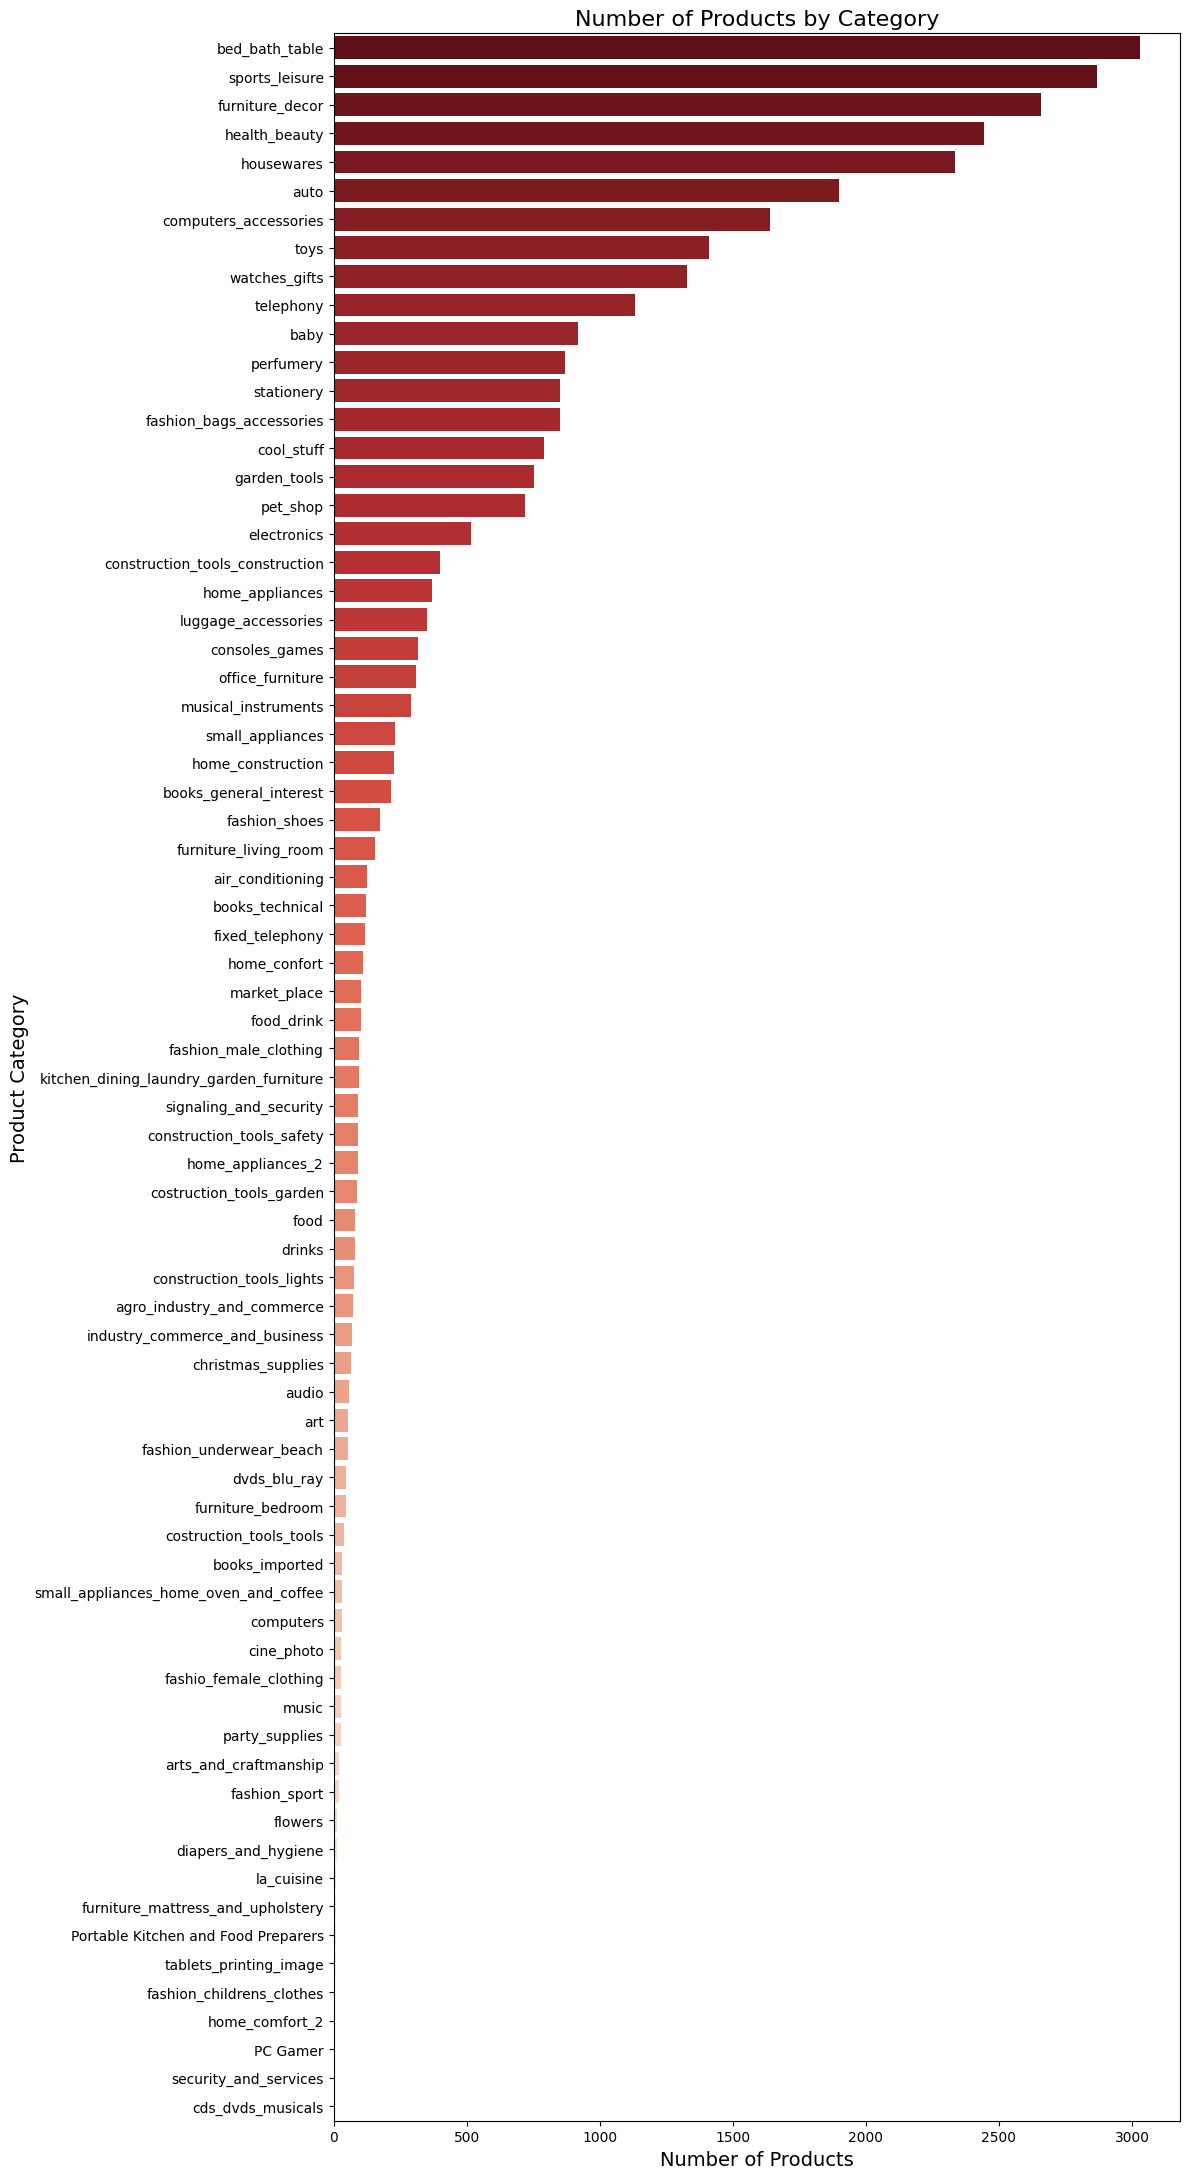

In [ ]:
category_products_df = category_products.reset_index()
category_products_df.columns = ['Category', 'Product Count']

# 수평 막대 그래프 시각화
plt.figure(figsize=(12, len(category_products_df) * 0.3))  # 데이터 수에 따라 그래프 크기 조정
sns.barplot(data=category_products_df, y='Category', x='Product Count', palette='Reds_r',hue='Category')
plt.title('Number of Products by Category', fontsize=16)
plt.xlabel('Number of Products', fontsize=14)
plt.ylabel('Product Category', fontsize=14)
plt.tight_layout()  # 그래프 레이아웃 최적화
plt.show()


---
- 상품 매출 분포

In [ ]:
Order_Payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [ ]:
category_products_merge = Order_Items.merge(Products,on='product_id',how='left')

In [ ]:
category_products_merge = category_products_merge.merge(Order_Payments,on='order_id',how='left')

In [ ]:
# 평균 매출 계산
avg_price = category_products_merge.groupby('product_category_name')['price'].mean().sort_values(ascending=False)
avg_price

product_category_name
computers                                1103.689136
small_appliances_home_oven_and_coffee     627.509103
home_appliances_2                         459.945187
agro_industry_and_commerce                332.706151
musical_instruments                       293.772604
                                            ...     
food_drink                                 56.621211
cds_dvds_musicals                          52.142857
diapers_and_hygiene                        40.194615
flowers                                    33.637576
home_comfort_2                             24.940968
Name: price, Length: 73, dtype: float64

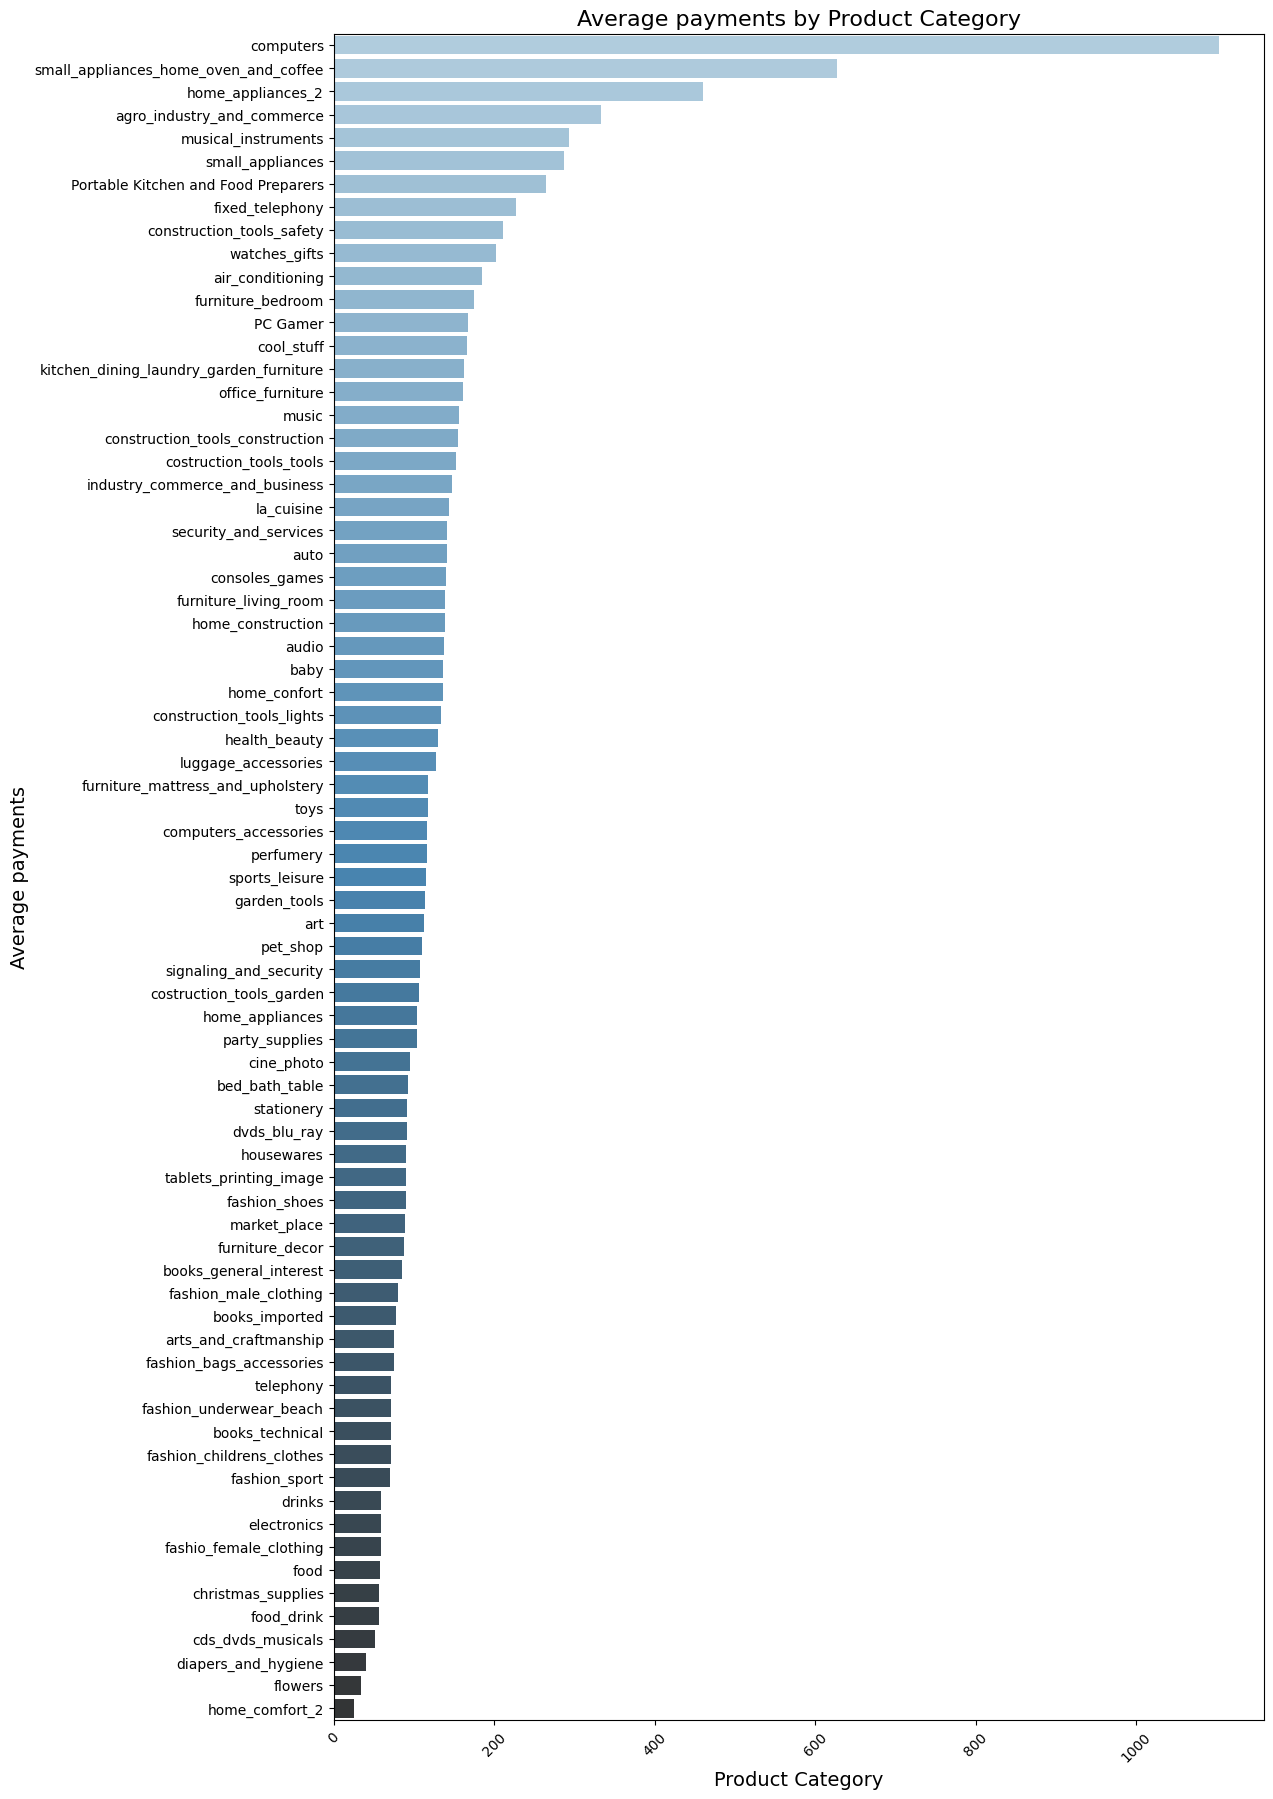

In [ ]:
# 바 차트 생성
plt.figure(figsize=(12, len(category_products_df) * 0.3))
sns.barplot(y=avg_price.index,x=avg_price.values, palette='Blues_d', hue=avg_price.index)
plt.title('Average payments by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Average payments', fontsize=14)
plt.xticks(rotation=45)
plt.show()


- 카테고리별 주문 건수

In [ ]:
# 카테고리별 주문 횟수
category_order_counts = category_products_merge['product_category_name'].value_counts()

# 결과 출력
print("카테고리별 주문 건수:")
print(category_order_counts)


카테고리별 주문 건수:
product_category_name
bed_bath_table               11115
health_beauty                 9670
sports_leisure                8641
furniture_decor               8334
computers_accessories         7827
                             ...  
cds_dvds_musicals               14
la_cuisine                      14
PC Gamer                         9
fashion_childrens_clothes        8
security_and_services            2
Name: count, Length: 73, dtype: int64


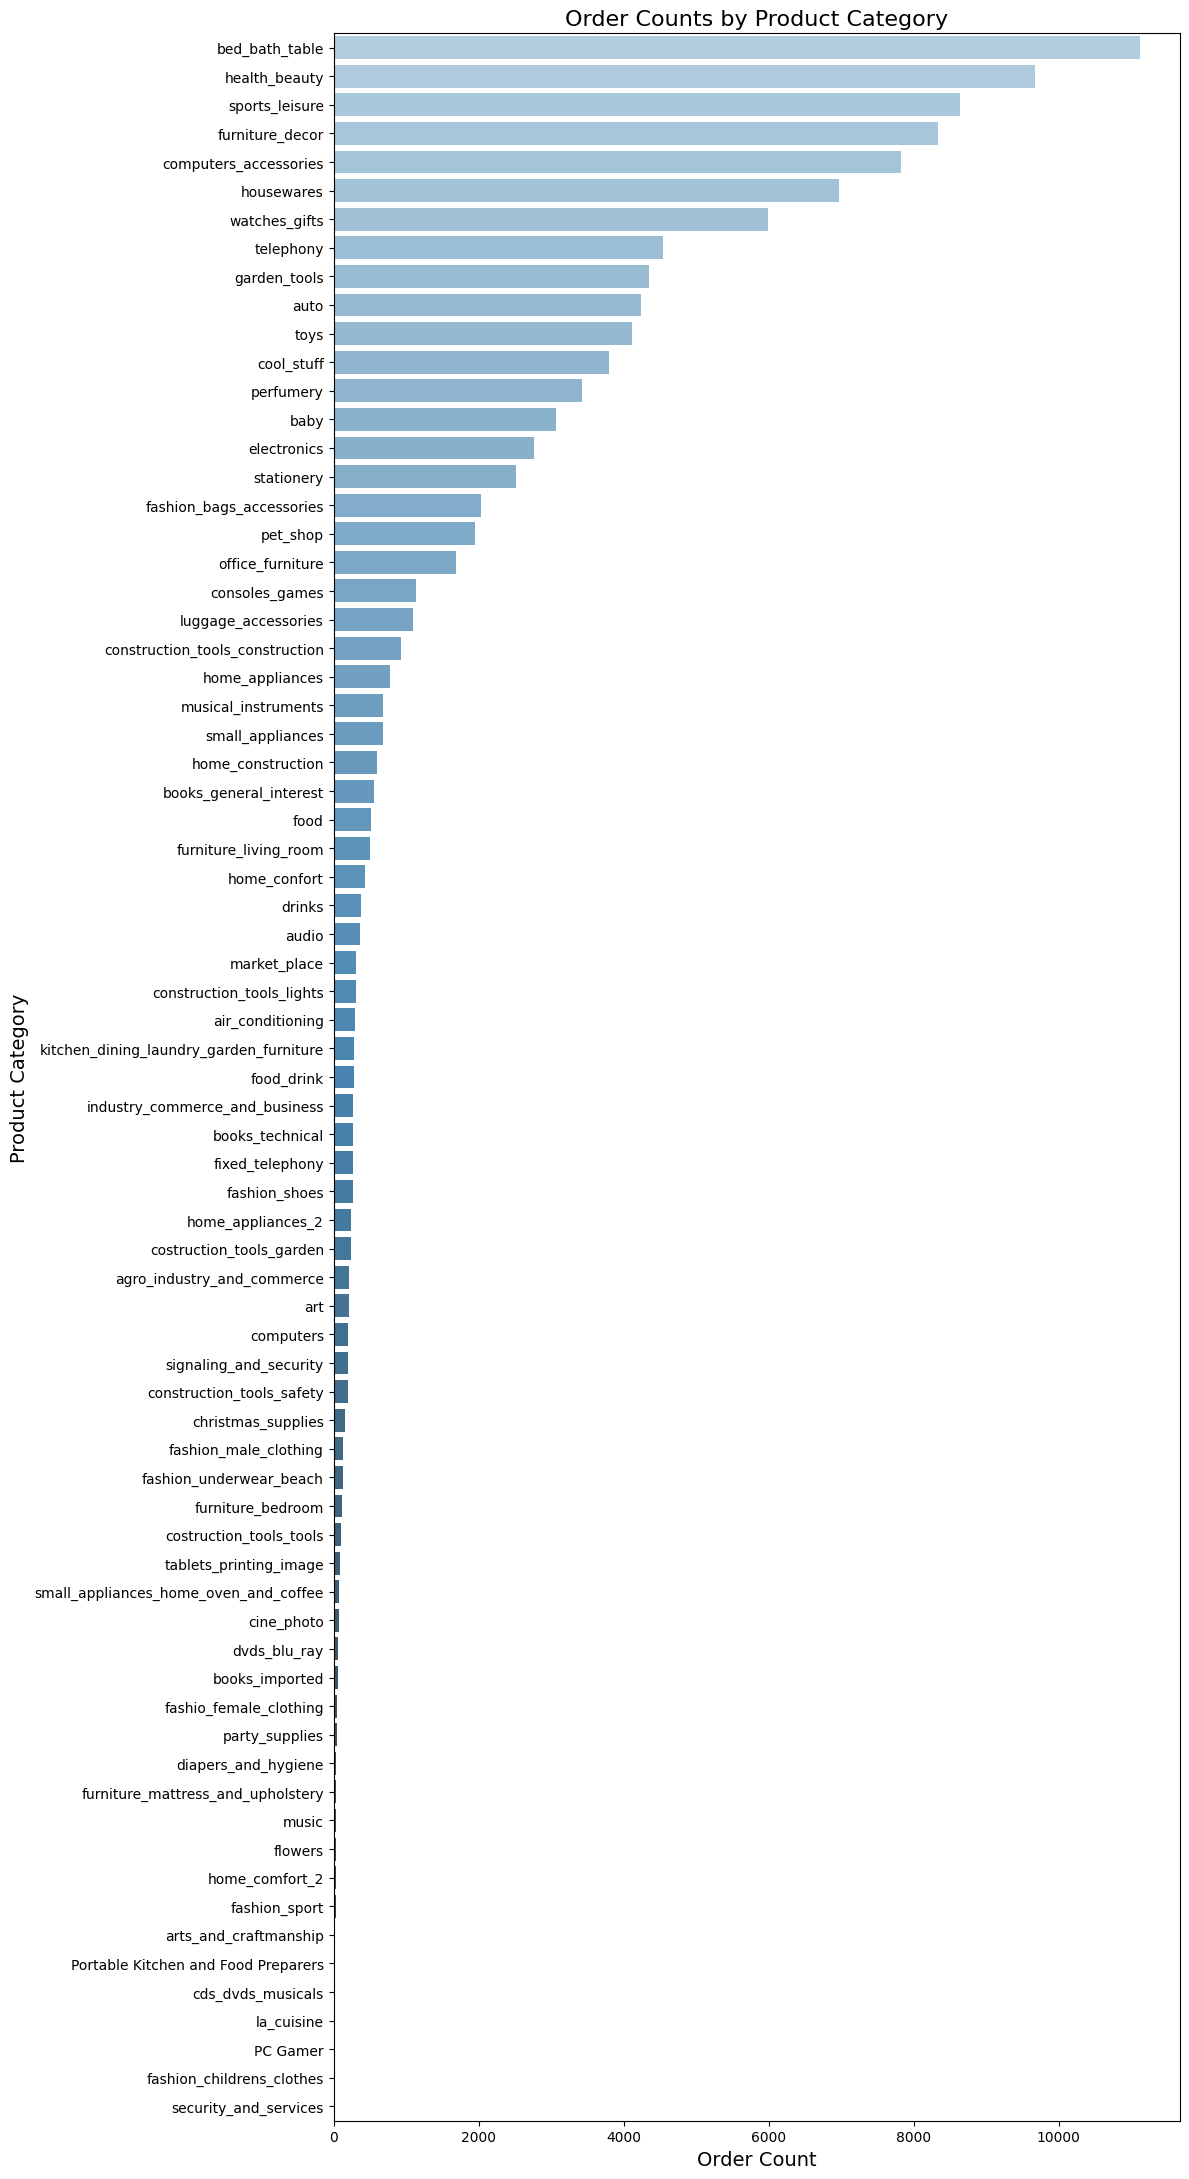

In [ ]:
plt.figure(figsize=(12, len(category_order_counts) * 0.3))
sns.barplot(
    y=category_order_counts.index,
    x=category_order_counts.values,
    palette='Blues_d',
    hue=category_order_counts.index,
    dodge=False,
)
plt.title('Order Counts by Product Category', fontsize=16)
plt.xlabel('Order Count', fontsize=14)
plt.ylabel('Product Category', fontsize=14)
plt.tight_layout()
plt.show()

- 매출이 가장 높은 top10 카테고리를 분석

In [ ]:
category_products_merge

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,housewares,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,computers_accessories,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,sports_leisure,43.0,869.0,1.0,967.0,21.0,24.0,19.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,computers_accessories,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


In [ ]:
category_sales = category_products_merge.groupby('product_category_name')['price'].sum().sort_values(ascending=False)


#### 4. `리뷰 및 품질` 관련  
- 카테고리별 리뷰 수

In [ ]:
category_products_review_merge = category_products_merge.merge(Order_Reviews,on='order_id',how='left')

In [ ]:
category_products_review_merge

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,650.0,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,30000.0,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,59.0,695.0,...,3050.0,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,42.0,480.0,...,200.0,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,59.0,409.0,...,3750.0,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,housewares,43.0,1002.0,...,10150.0,89.0,15.0,40.0,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47
113310,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,computers_accessories,31.0,232.0,...,8950.0,45.0,26.0,38.0,be803f6a93d64719fd685c1cc610918a,5.0,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29
113311,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,sports_leisure,43.0,869.0,...,967.0,21.0,24.0,19.0,dbdd81cd59a1a9f94a10a990b4d48dce,5.0,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52
113312,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,computers_accessories,56.0,1306.0,...,100.0,20.0,20.0,20.0,fba117c9ac40d41ca7be54741f471303,5.0,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05


In [ ]:
# 카테고리별 리뷰 수 계산
category_review_counts = category_products_review_merge.groupby('product_category_name')['review_id'].count().sort_values(ascending=False)

In [ ]:
# 카테고리별 평점 평균 계산
category_score_avg = category_products_review_merge.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)

In [ ]:
print("카테고리별 리뷰 수:")
print(category_review_counts.head(10))  # 상위 10개 카테고리 출력
print("\n카테고리별 평균 평점:")
print(category_score_avg.head(10))  # 상위 10개 카테고리 출력

카테고리별 리뷰 수:
product_category_name
bed_bath_table           11137
health_beauty             9645
sports_leisure            8640
furniture_decor           8331
computers_accessories     7849
housewares                6943
watches_gifts             5950
telephony                 4517
garden_tools              4329
auto                      4213
Name: review_id, dtype: int64

카테고리별 평균 평점:
product_category_name
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.446266
costruction_tools_tools                  4.444444
flowers                                  4.419355
books_imported                           4.400000
books_technical                          4.368421
food_drink                               4.315412
luggage_accessories                      4.315257
small_appliances_home_oven_and_coffee    4.302632
Name: review_score, dtype: float64


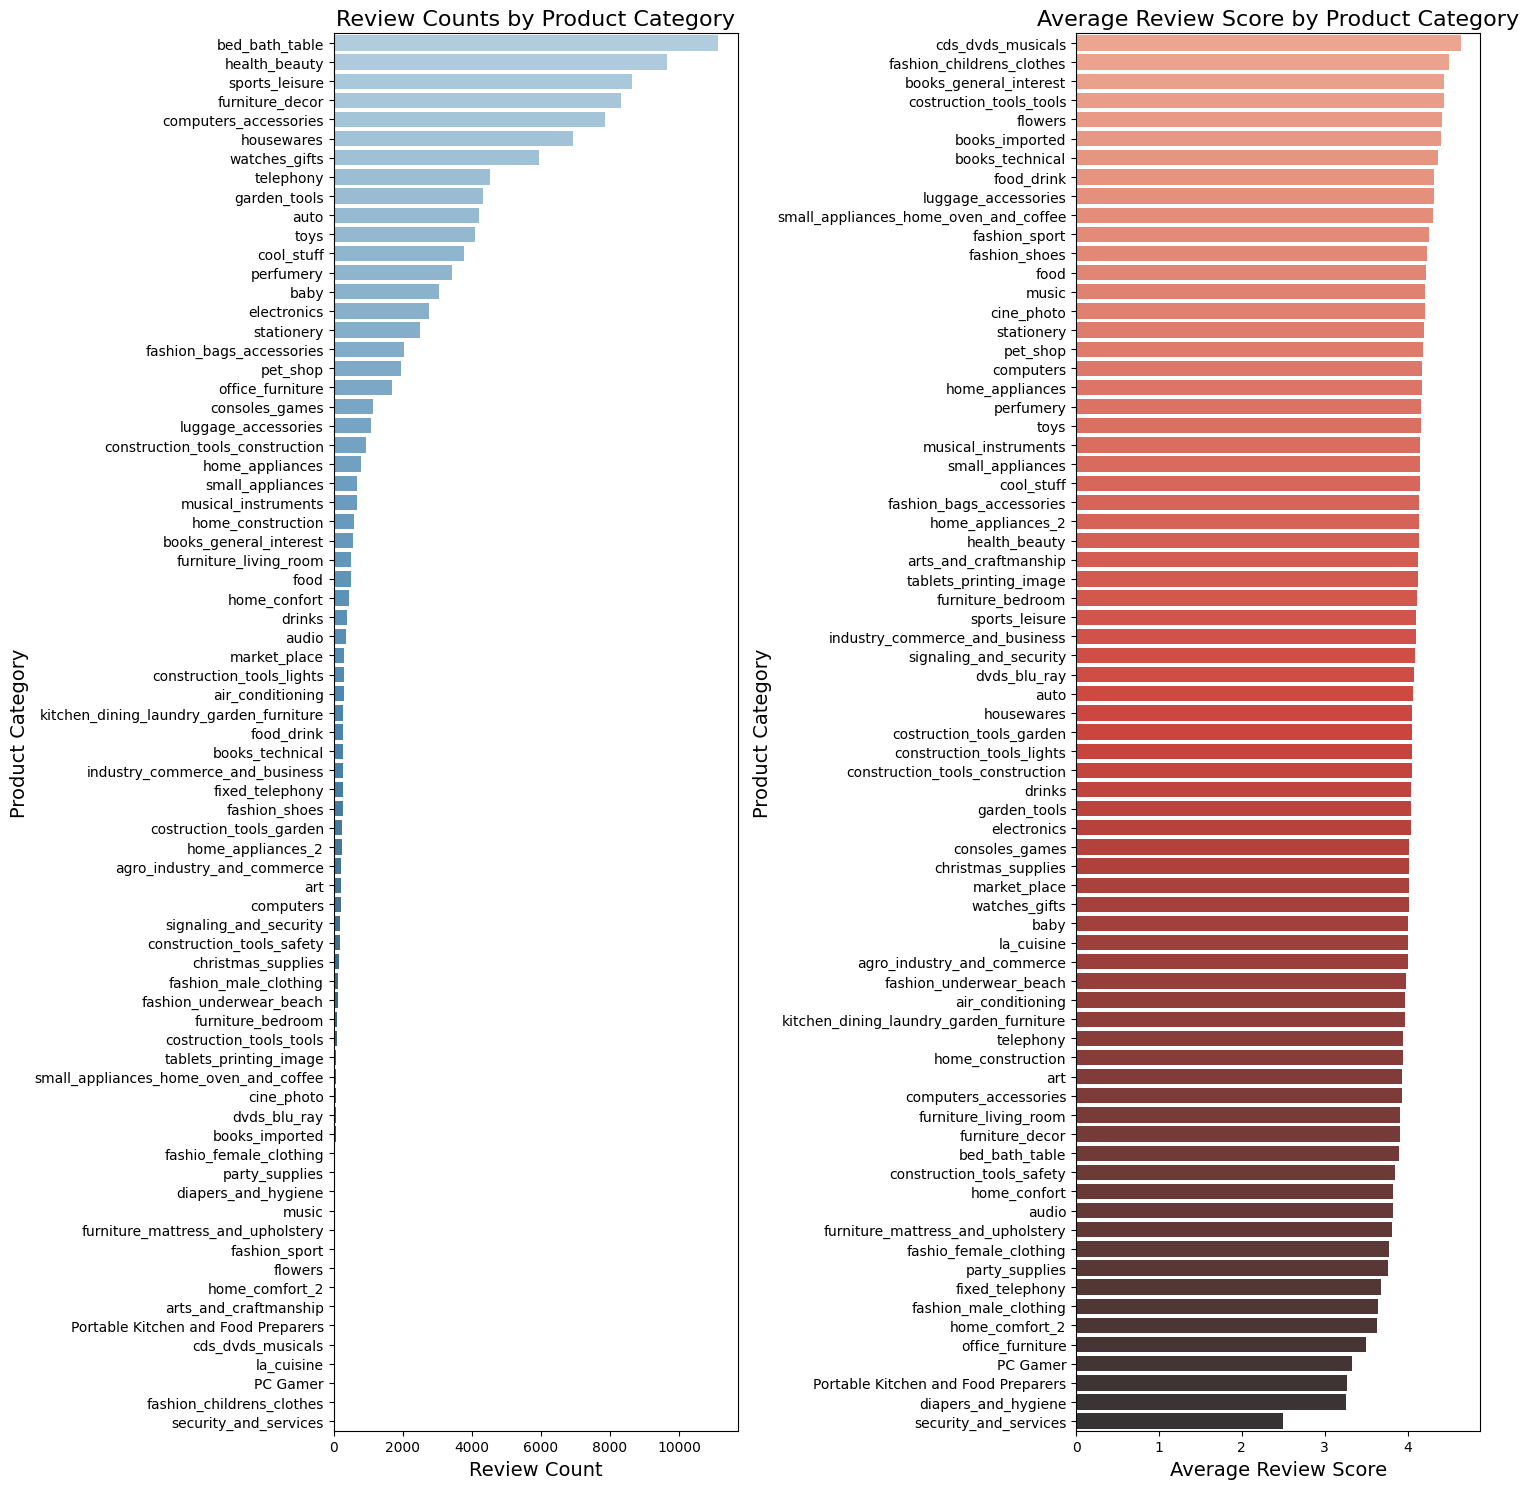

In [ ]:
# 리뷰 수와 평점 평균 시각화
plt.figure(figsize=(15, 15))

# 리뷰 수 시각화
plt.subplot(1, 2, 1)
sns.barplot(y=category_review_counts.index, x=category_review_counts.values, palette='Blues_d',hue=category_review_counts.index)
plt.title('Review Counts by Product Category', fontsize=16)
plt.xlabel('Review Count', fontsize=14)
plt.ylabel('Product Category', fontsize=14)

# 평점 평균 시각화
plt.subplot(1, 2, 2)
sns.barplot(y=category_score_avg.index, x=category_score_avg.values, palette='Reds_d',hue=category_review_counts.index)
plt.title('Average Review Score by Product Category', fontsize=16)
plt.xlabel('Average Review Score', fontsize=14)
plt.ylabel('Product Category', fontsize=14)

plt.legend([], frameon=False)
plt.tight_layout()
plt.show()

***
# 3. (심화) 핵심 성과 지표

In [ ]:
Customers = pd.read_csv('olist_customers_dataset.csv')
Order_Items = pd.read_csv('olist_order_items_dataset.csv')
Order_Payments = pd.read_csv('olist_order_payments_dataset.csv')
Order_Reviews = pd.read_csv('olist_order_reviews_dataset.csv')
Orders = pd.read_csv('olist_orders_dataset.csv')
Products = pd.read_csv('olist_products_dataset.csv')
Sellers = pd.read_csv('olist_sellers_dataset.csv')
Category_Translation = pd.read_csv('product_category_name_translation.csv')
data = Orders

In [ ]:
df = data.merge(Order_Items, on='order_id', how='left') # orders + Order_Items
df = df.merge(Order_Reviews, on='order_id', how='left')
df = df.merge(Order_Payments, on='order_id', how='left')
df = df.merge(Products, on='product_id', how='left')
df = df.merge(Customers, on='customer_id', how='left')
df = df.merge(Sellers, on='seller_id', how='left')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   order_item_id                  118310 non-null  float64
 9   product_id                     118310 non-null  object 
 10  seller_id                      118310 non-null  object 
 11  shipping_limit_date            118310 non-null  object 
 12  price                         

In [ ]:
df.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
review_id                           997
review_score                        997
review_comment_title             105154
review_comment_message            68898
review_creation_date                997
review_answer_timestamp             997
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
product_category_name              2542


In [ ]:
df.isna().mean()*100

order_id                          0.000000
customer_id                       0.000000
order_status                      0.000000
order_purchase_timestamp          0.000000
order_approved_at                 0.148561
order_delivered_carrier_date      1.750837
order_delivered_customer_date     2.871339
order_estimated_delivery_date     0.000000
order_item_id                     0.699160
product_id                        0.699160
seller_id                         0.699160
shipping_limit_date               0.699160
price                             0.699160
freight_value                     0.699160
review_id                         0.836810
review_score                      0.836810
review_comment_title             88.258647
review_comment_message           57.827988
review_creation_date              0.836810
review_answer_timestamp           0.836810
payment_sequential                0.002518
payment_type                      0.002518
payment_installments              0.002518
payment_val

---

In [ ]:
# datetime 형식으로 변환
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

# 리드타임 계산
df['leadtime'] = df['order_delivered_customer_date'] - df['order_purchase_timestamp']
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,leadtime
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,8 days 10:28:40
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,8 days 10:28:40
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,8 days 10:28:40
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,13 days 18:46:08
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,9 days 09:27:40


In [ ]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'leadtime'],
      dtype='object')

- 리드타임 대비 리뷰

In [ ]:
selected_columns = ['product_category_name', 'leadtime', 'review_score']

df_selected = df[selected_columns].sort_values(by='leadtime', ascending=True)

df_selected


,product_category_name,leadtime,review_score
37853,brinquedos,0 days 12:48:07,5.0
50095,utilidades_domesticas,0 days 18:45:10,3.0
46509,cama_mesa_banho,0 days 20:31:39,3.0
116677,cama_mesa_banho,0 days 20:43:20,1.0
116681,cama_mesa_banho,0 days 20:43:20,1.0
...,...,...,...
118946,NaN,NaT,5.0
118995,relogios_presentes,NaT,1.0
119039,NaN,NaT,4.0
119040,NaN,NaT,1.0


In [ ]:
# leadtime_days 계산 시 .loc 사용
df_selected.loc[:, 'leadtime_days'] = df_selected['leadtime'].dt.days

# 정렬
df_selected_sorted = df_selected.sort_values(by='leadtime_days', ascending=False)
df_selected_sorted.head(3)


,product_category_name,leadtime,review_score,leadtime_days
23417,automotivo,209 days 15:05:12,NaN,209.0
66581,cool_stuff,208 days 08:26:32,2.0,208.0
73634,consoles_games,195 days 15:12:59,1.0,195.0


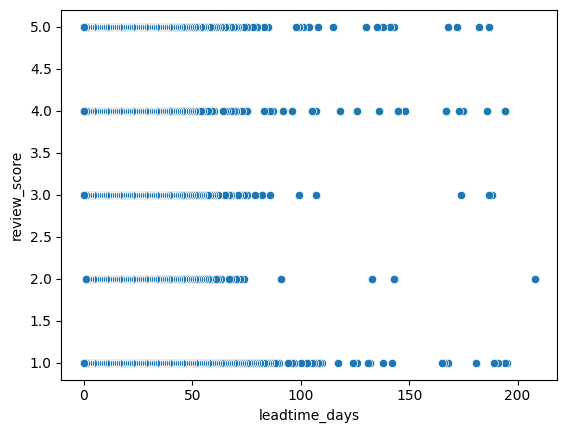

In [ ]:
sns.scatterplot(x='leadtime_days',y='review_score',data=df_selected_sorted)
plt.show()

In [ ]:
correlation = df_selected_sorted[['leadtime_days', 'review_score']].corr()
correlation

,leadtime_days,review_score
leadtime_days,1.000000,-0.304796
review_score,-0.304796,1.000000


leadtime_days가 증가할수록 review_score는 다소 감소하는 경향 (높진않음)

## 배송 지연의 원인 찾기

각 단계별 시간 계산과 중앙값 계산

In [ ]:
# 승인 처리 시간
Orders['approval_processing_time'] = (
    Orders['order_approved_at'] - Orders['order_purchase_timestamp']
)

# 물류 전달 시간
Orders['carrier_transfer_time'] = (
    Orders['order_delivered_carrier_date'] - Orders['order_approved_at']
)

# 배송 소요 시간
Orders['delivery_duration'] = (
    Orders['order_delivered_customer_date'] - Orders['order_delivered_carrier_date']
)

In [ ]:
# 중앙값 계산
approval_median = Orders['approval_processing_time'].median()
carrier_transfer_median = Orders['carrier_transfer_time'].median()
delivery_duration_median = Orders['delivery_duration'].median()

# 새로운 열 추가 및 평가
Orders['approval_state_Delay'] = Orders['approval_processing_time'].apply(
    lambda x: 1 if pd.notnull(x) and x > approval_median else 0
)
Orders['carrier_transfer_state_Delay'] = Orders['carrier_transfer_time'].apply(
    lambda x: 1 if pd.notnull(x) and x > carrier_transfer_median else 0
)
Orders['delivery_state_Delay'] = Orders['delivery_duration'].apply(
    lambda x: 1 if pd.notnull(x) and x > delivery_duration_median else 0
)

# 결과 확인
Orders[['approval_processing_time', 'approval_state_Delay',
        'carrier_transfer_time', 'carrier_transfer_state_Delay',
        'delivery_duration', 'delivery_state_Delay']]

,approval_processing_time,approval_state_Delay,carrier_transfer_time,carrier_transfer_state_Delay,delivery_duration,delivery_state_Delay
0,0 days 00:10:42,0,2 days 08:47:45,1,6 days 01:30:13,0
1,1 days 06:42:50,1,0 days 11:06:33,0,12 days 00:56:45,1
2,0 days 00:16:34,0,0 days 04:54:37,0,9 days 04:16:29,1
3,0 days 00:17:53,0,3 days 17:54:00,1,9 days 10:48:43,1
4,0 days 01:01:50,1,0 days 21:26:05,0,1 days 22:30:28,0
...,...,...,...,...,...,...
99436,0 days 00:00:00,0,1 days 01:23:58,0,7 days 03:49:58,1
99437,0 days 00:11:39,0,1 days 10:12:05,0,20 days 18:15:14,1
99438,0 days 00:17:33,0,1 days 05:48:10,0,23 days 14:31:51,1
99439,0 days 00:07:54,0,3 days 17:58:42,1,13 days 07:57:51,1


- 시간 컬럼(order_purchase_timestamp)을 기준으로  
approval_processing_time(승인처리시간),  
carrier_transfer_time(물류전달시간),  
delivery_duration(배송소요시간)의 평균을 시계열로 시각화.  

In [ ]:
Orders['purchase_month'] = Orders['order_purchase_timestamp'].dt.to_period('M')

monthly_trends = Orders.groupby('purchase_month')[['approval_processing_time',
                                                   'carrier_transfer_time',
                                                   'delivery_duration']].mean()
monthly_trends

,approval_processing_time,carrier_transfer_time,delivery_duration
purchase_month,,,
2016-09,22 days 06:44:13,32 days 02:26:01.500000,1 days 14:35:45
2016-10,1 days 12:23:42.106918239,13 days 03:35:17.985611510,5 days 19:35:06.925925925
2016-12,0 days 00:14:50,3 days 06:42:50,1 days 09:40:17
2017-01,0 days 11:41:28.314930991,2 days 23:44:52.523560209,9 days 04:46:25.570666666
2017-02,0 days 10:17:42.578142695,3 days 07:00:34.688929001,9 days 12:50:50.061101028
2017-03,0 days 06:00:41.598134328,2 days 21:07:55.068313392,9 days 20:00:06.071877454
2017-04,0 days 13:19:43.402916666,3 days 03:26:01.273384353,11 days 05:38:34.541033434
2017-05,0 days 10:00:24.509214092,2 days 13:38:08.734722222,8 days 08:09:56.871368124
2017-06,0 days 09:28:32.225547670,2 days 17:49:00.980201131,8 days 21:06:48.584688995


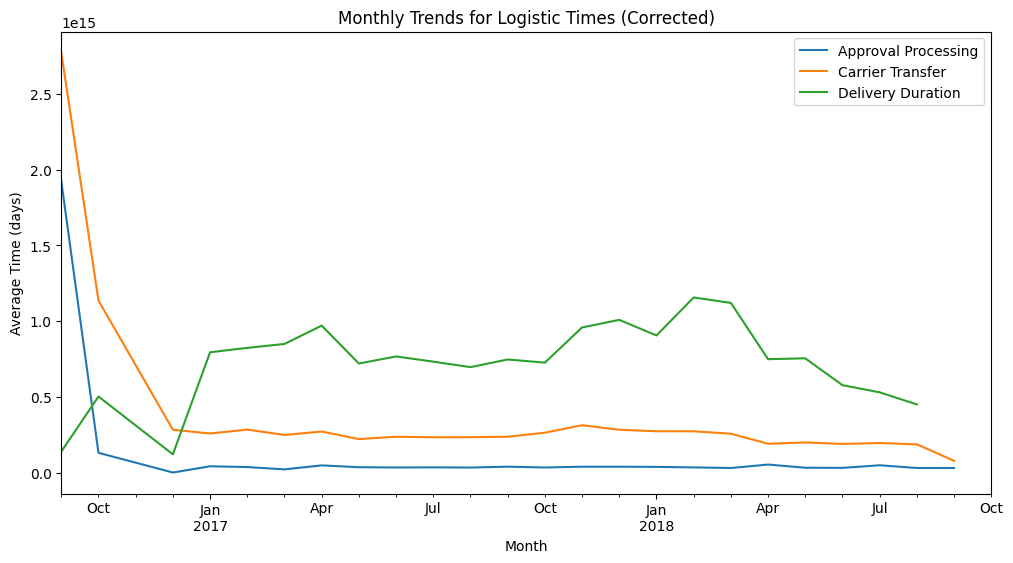

In [ ]:
# 그래프 생성
monthly_trends.plot(figsize=(12, 6))
plt.title('Monthly Trends for Logistic Times (Corrected)')
plt.xlabel('Month')
plt.ylabel('Average Time (days)')
plt.legend(['Approval Processing', 'Carrier Transfer', 'Delivery Duration'])
plt.show()


승인처리시간과 물류 전달시간은 안정적이나  
배송소요시간은 변동폭이 크다.
___
## 지역별 소요시간

In [ ]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'leadtime'],
      dtype='object')

In [ ]:
# 구매자 우편번호 도시 주
region = df[['order_id','customer_zip_code_prefix', 'customer_city', 'customer_state',
'order_id','seller_zip_code_prefix', 'seller_city', 'seller_state','leadtime']]

In [ ]:
# 고객 주(state)별 평균 리드타임 계산
state_leadtime = region.groupby('customer_state')['leadtime'].mean().sort_values(ascending=False).reset_index()

# 고객 도시(city)별 평균 리드타임 계산
city_leadtime = region.groupby('customer_city')['leadtime'].mean().sort_values(ascending=False).reset_index()


In [ ]:
# 결과 출력
print("주(state)별 평균 리드타임:")
print(state_leadtime)

주(state)별 평균 리드타임:
   customer_state                   leadtime
0              RR 28 days 05:32:39.391304348
1              AP 28 days 02:37:32.963855421
2              AM 26 days 11:53:47.852941176
3              AL 24 days 15:06:13.440449438
4              PA 23 days 17:16:08.127620784
5              MA 21 days 15:15:45.781287970
6              SE 21 days 08:59:05.645077720
7              CE 20 days 19:05:24.779920212
8              PB 20 days 14:00:05.967948718
9              AC 20 days 13:26:51.563829787
10             RO 19 days 16:40:48.526690391
11             RN 19 days 15:35:52.147424511
12             PI 19 days 08:15:28.794223826
13             BA 19 days 04:56:04.470126582
14             PE 18 days 06:10:19.952173913
15             MT 17 days 23:15:55.695933456
16             TO 17 days 03:05:44.610778443
17             ES 15 days 16:35:29.096203623
18             MS 15 days 11:38:45.936320754
19             GO 15 days 08:40:52.566597077
20             RJ 15 days 05:40:35.9

In [ ]:
# 결과 출력
print("도시(city)별 평균 리드타임:")
print(city_leadtime)

도시(city)별 평균 리드타임:
                 customer_city                   leadtime
0                  novo brasil          148 days 04:11:17
1            capinzal do norte   109 days 01:48:02.500000
2            adhemar de barros           97 days 11:14:39
3          santa cruz de goias 86 days 17:19:22.666666667
4                        arace    86 days 09:41:40.750000
...                        ...                        ...
4114    santo antonio de goias                        NaT
4115       sao domingos do sul                        NaT
4116              sao fernando                        NaT
4117  sao francisco do humaita                        NaT
4118      sao joao do itaperiu                        NaT

[4119 rows x 2 columns]


***
## 배송비 책정 정책

In [ ]:
# 상관관계 계산
correlation = merged_data[['freight_value', 'price', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].corr()

correlation


,freight_value,price,product_weight_g,product_length_cm,product_height_cm,product_width_cm
freight_value,1.000000,0.414204,0.610420,0.309086,0.391831,0.323777
price,0.414204,1.000000,0.338819,0.145811,0.223602,0.172467
product_weight_g,0.610420,0.338819,1.000000,0.460919,0.583277,0.506609
product_length_cm,0.309086,0.145811,0.460919,1.000000,0.192895,0.532537
product_height_cm,0.391831,0.223602,0.583277,0.192895,1.000000,0.281224
product_width_cm,0.323777,0.172467,0.506609,0.532537,0.281224,1.000000


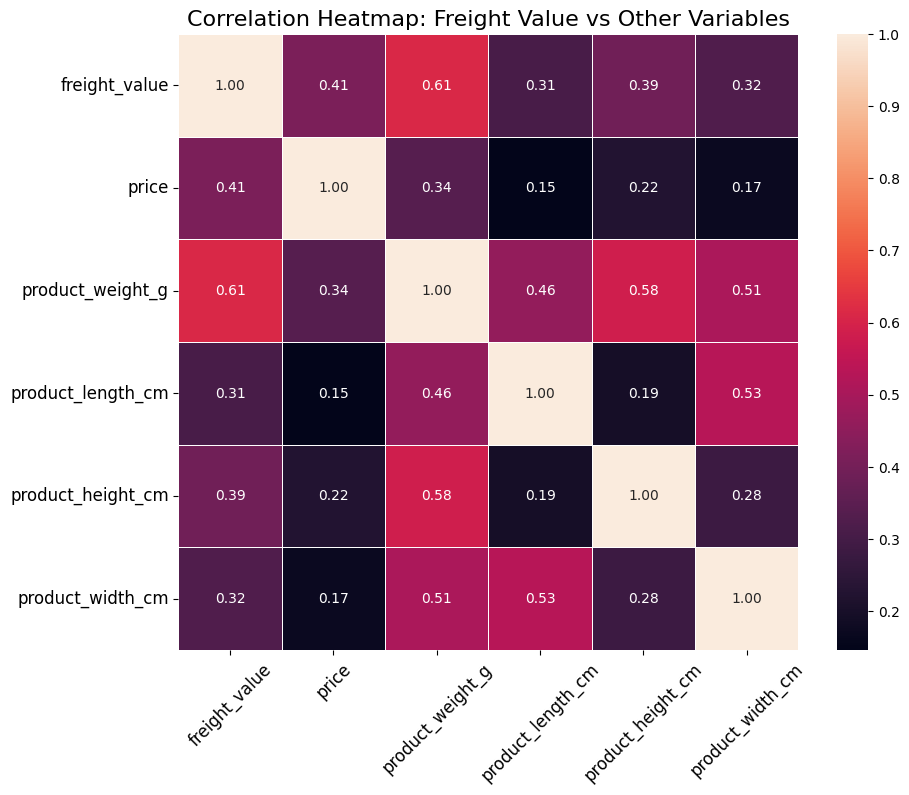

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Freight Value vs Other Variables", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

무거울수록 배송비가 많이든다

/var/folders/b8/3v2wwvpj5j90k29tbr4zfpbm0000gn/T/ipykernel_8968/3166525100.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_freight_by_weight = merged_data.groupby('weight_range')['freight_value'].mean()


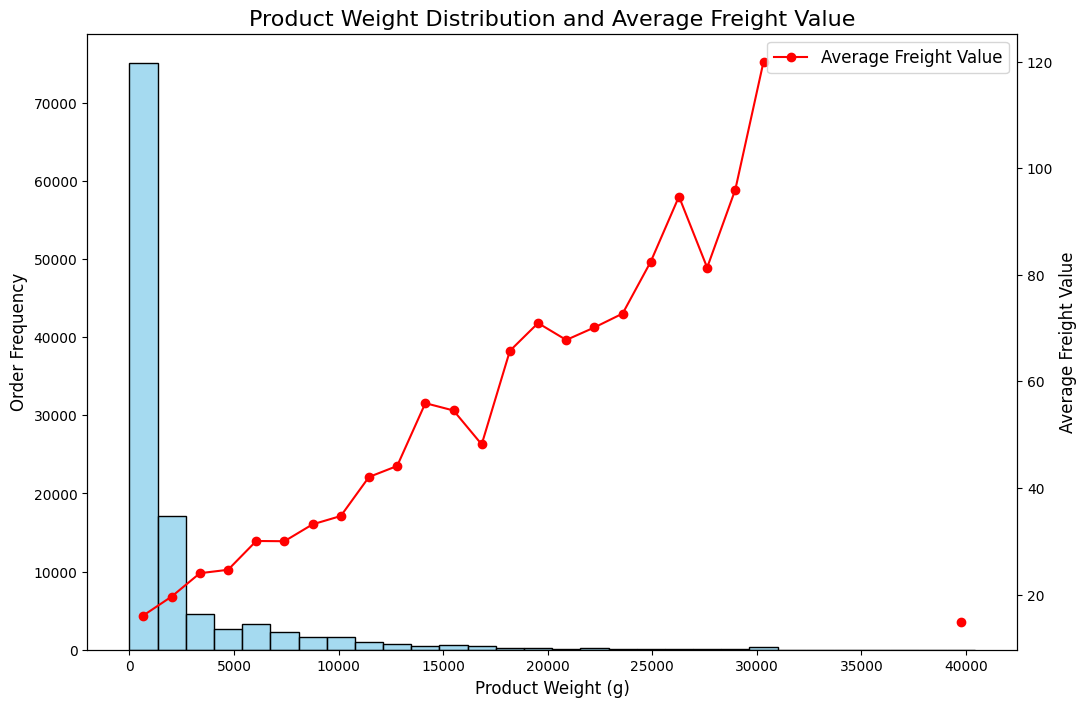

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

merged_data['weight_range'] = pd.cut(merged_data['product_weight_g'], bins=30)
average_freight_by_weight = merged_data.groupby('weight_range')['freight_value'].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.histplot(data=merged_data, x='product_weight_g', bins=30, kde=False, ax=ax1, color="skyblue")
ax1.set_ylabel('Order Frequency', fontsize=12)
ax1.set_xlabel('Product Weight (g)', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.set_title('Product Weight Distribution and Average Freight Value', fontsize=16)

ax2 = ax1.twinx()
ax2.plot(average_freight_by_weight.index.categories.mid, average_freight_by_weight, color="red", marker="o", label="Average Freight Value")
ax2.set_ylabel('Average Freight Value', fontsize=12)
ax2.tick_params(axis='y', labelsize=10)

ax2.legend(loc="upper right", fontsize=12)

plt.show()


In [ ]:
df.to_csv('data.csv')

## 결론

### 1. 배송비와 상품 무게의 관계
- 히스토그램과 선 그래프 분석 결과, **상품 무게가 증가할수록 평균 배송비가 증가**하는 경향이 확인되었습니다.
- 상품 무게가 가벼운 경우 주문 빈도가 높지만, 배송비에는 큰 영향을 주지 않음. 배송 정책에서 이 점을 활용 가능.

---

### 2. 배송 소요 시간
- 지역별, 도시별 **평균 리드타임 분석** 결과, 특정 지역이나 도시에 배송 시간이 오래 걸리는 패턴이 있다면 물류 네트워크를 최적화할 필요가 있음.

---

### 3. 배송비 책정 정책
- 상관행렬을 통해 **배송비는 주로 무게와 관련**이 깊지만, **상품 크기(길이, 높이, 너비)** 와도 다소 연관이 있음을 확인.
- 상품 크기와 무게를 결합한 **복합 요인 기반 배송비 책정 정책**을 도입 가능.

---

### 4. 객단가 및 매출
- 특정 카테고리(예: 컴퓨터, 소형 주방 기기 등)의 **객단가**가 다른 카테고리보다 현저히 높음.
- 이러한 고가 상품에 대해 **무료배송 또는 특별 배송 옵션**을 제공하여 구매를 유도 가능.

---

### 5. 추천사항
1. **배송 최적화**:
   - 배송비가 높거나 리드타임이 긴 지역에 물류 센터를 증설하거나 배송 경로를 개선하여 고객 만족도를 높일 수 있음.

2. **프로모션 전략**:
   - 특정 금액 이상 구매 시 **무료배송 제공**.
   - 묶음배송 혜택 강화로 **객단가 증대**.

3. **고가 상품 타겟팅**:
   - 객단가가 높은 상품군(예: 컴퓨터, 소형 주방 기기)에 대해 광고, 리뷰 활성화 등을 통해 **구매 전환율 상승** 가능.

---

### 결론 요약
- 무게와 크기를 고려한 배송비 최적화 및 고가 상품군의 특별 프로모션이 **객단가 상승과 고객 만족도 향상**에 기여할 것으로 기대됩니다.
